# NLP-based Conflict Prediction: Preliminary Analysis

#### NLP-based Conflict Prediction: Preliminary Analysis
#### Uses both UNGDC speeches and structured geopolitical conflict data

In [4]:
import os
import sys
import pandas as pd
import numpy as np

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [5]:
# Download resources
nltk.download('vader_lexicon', quiet=True)

True

# PART 1: UNGDC ANALYSIS - Sentiment and Threat Keywords

In [6]:
print("\nLoading UNGDC dataset...")
UNGDC_CSV = "UNGDC_1946-2023.csv"
if not os.path.exists(UNGDC_CSV):
    print(f"ERROR: Dataset {UNGDC_CSV} not found in the current directory.")
    sys.exit(1)


Loading UNGDC dataset...


In [7]:
ungdc = pd.read_csv(UNGDC_CSV, low_memory=False)
ungdc = ungdc.dropna(subset=['country', 'year', 'text'])
ungdc['year'] = pd.to_numeric(ungdc['year'], errors='coerce')
ungdc = ungdc.dropna(subset=['year'])
ungdc['year'] = ungdc['year'].astype(int)

print(f"Loaded {len(ungdc)} speeches from {ungdc['country'].nunique()} countries")
print(f"Date range: {ungdc['year'].min()}-{ungdc['year'].max()}")

Loaded 3093 speeches from 151 countries
Date range: 2000-2020


In [10]:
# Sentiment analysis using VADER
print("Computing sentiment...")
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    try:
        return sia.polarity_scores(str(text))['compound']
    except Exception:
        return 0.0

ungdc['sentiment'] = ungdc['text'].apply(get_sentiment)

Computing sentiment...


In [11]:
# Threat keyword detection
print("Counting threat keywords...")
THREAT_KEYWORDS = {
    'weapon', 'attack', 'military', 'bomb', 'terrorist', 'rebel', 'war', 
    'conflict', 'army', 'violence', 'security', 'hostility', 'aggression', 
    'threat', 'crisis', 'danger', 'missile', 'nuclear', 'siege', 'invasion'
}

def count_threat_keywords(text):
    try:
        text_lower = str(text).lower()
        return sum(text_lower.count(keyword) for keyword in THREAT_KEYWORDS)
    except Exception:
        return 0

ungdc['threat_count'] = ungdc['text'].apply(count_threat_keywords)

Counting threat keywords...


In [12]:
# Aggregate by year
ungdc_agg = ungdc.groupby(['country', 'year']).agg({
    'sentiment': ['mean', 'std', 'count'],
    'threat_count': 'sum'
}).reset_index()

ungdc_agg.columns = ['country', 'year', 'sentiment_mean', 'sentiment_std', 'speech_count', 'threat_count']

print(f"Aggregated: {len(ungdc_agg)} country-year records")
print(f"Total threat mentions: {ungdc_agg['threat_count'].sum()}")

Aggregated: 3093 country-year records
Total threat mentions: 85781


# PART 2: STRUCTURED DATASET - Escalation and Sentiment Correlation

In [13]:
DATA_CSV = "geopolitical_conflict_risk_dataset.csv"

if not os.path.exists(DATA_CSV):
    print(f"ERROR: Dataset {DATA_CSV} not found in the current directory.")
    sys.exit(1)

df = pd.read_csv(DATA_CSV)
df = df.dropna(subset=['region', 'month', 'social_media_sentiment', 'conflict_escalation_6m'])
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values('month')

In [18]:
print(f"Loaded {len(df)} records from {df['month'].min().date()} to {df['month'].max().date()}")
print(f"Regions: {', '.join(sorted(df['region'].unique()))}")

Loaded 1320 records from 2020-01-01 to 2025-06-01
Regions: East Asia, Eastern Europe, Middle East, North America, South America, South Asia, Western Europe


In [14]:
# Sentiment by region
region_sentiment = df.groupby('region')['social_media_sentiment'].mean().sort_values()

# Correlation
correlation = df['social_media_sentiment'].corr(df['conflict_escalation_6m'])
print(f"Sentiment-escalation correlation: {correlation:.3f}")

Sentiment-escalation correlation: -0.046


^^ No correlation

# PART 3: COMBINED ANALYSIS AND CLASSIFICATION

In [15]:
# Prepare features
sentiment_ts = df.groupby(['region', 'month'])['social_media_sentiment'].mean().reset_index()
sentiment_ts = sentiment_ts.rename(columns={'social_media_sentiment': 'sentiment'})

escalation_merge = df[['region', 'month', 'conflict_escalation_6m']].drop_duplicates()
features = sentiment_ts.merge(escalation_merge, on=['region', 'month'], how='left')
features = features.rename(columns={'conflict_escalation_6m': 'escalation'})
features = features.dropna(subset=['escalation'])

print(f"Features: {len(features)} region-month records")

Features: 698 region-month records


In [17]:
features.head()

,region,month,sentiment,escalation
0,East Asia,2020-01-01,-0.042865,0
1,East Asia,2020-01-01,-0.042865,1
2,East Asia,2020-02-01,0.231487,0
3,East Asia,2020-02-01,0.231487,1
4,East Asia,2020-03-01,0.245395,0


In [22]:
# Train model
X = features[['sentiment']].values
y = features['escalation'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)
preds = model.predict(X_test)

print(f"Training accuracy: {train_acc:.3f}")
print(f"Testing accuracy: {test_acc:.3f}")

# Compute confusion matrix and metrics
cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"  True Negatives: {tn}  |  False Positives: {fp}")
print(f"  False Negatives: {fn}  |  True Positives: {tp}")

Training accuracy: 0.602
Testing accuracy: 0.600

Confusion Matrix:
  True Negatives: 84  |  False Positives: 0
  False Negatives: 56  |  True Positives: 0


# PART 4: VISUALIZATIONS

✓ Saved: conflict_analysis_results.png


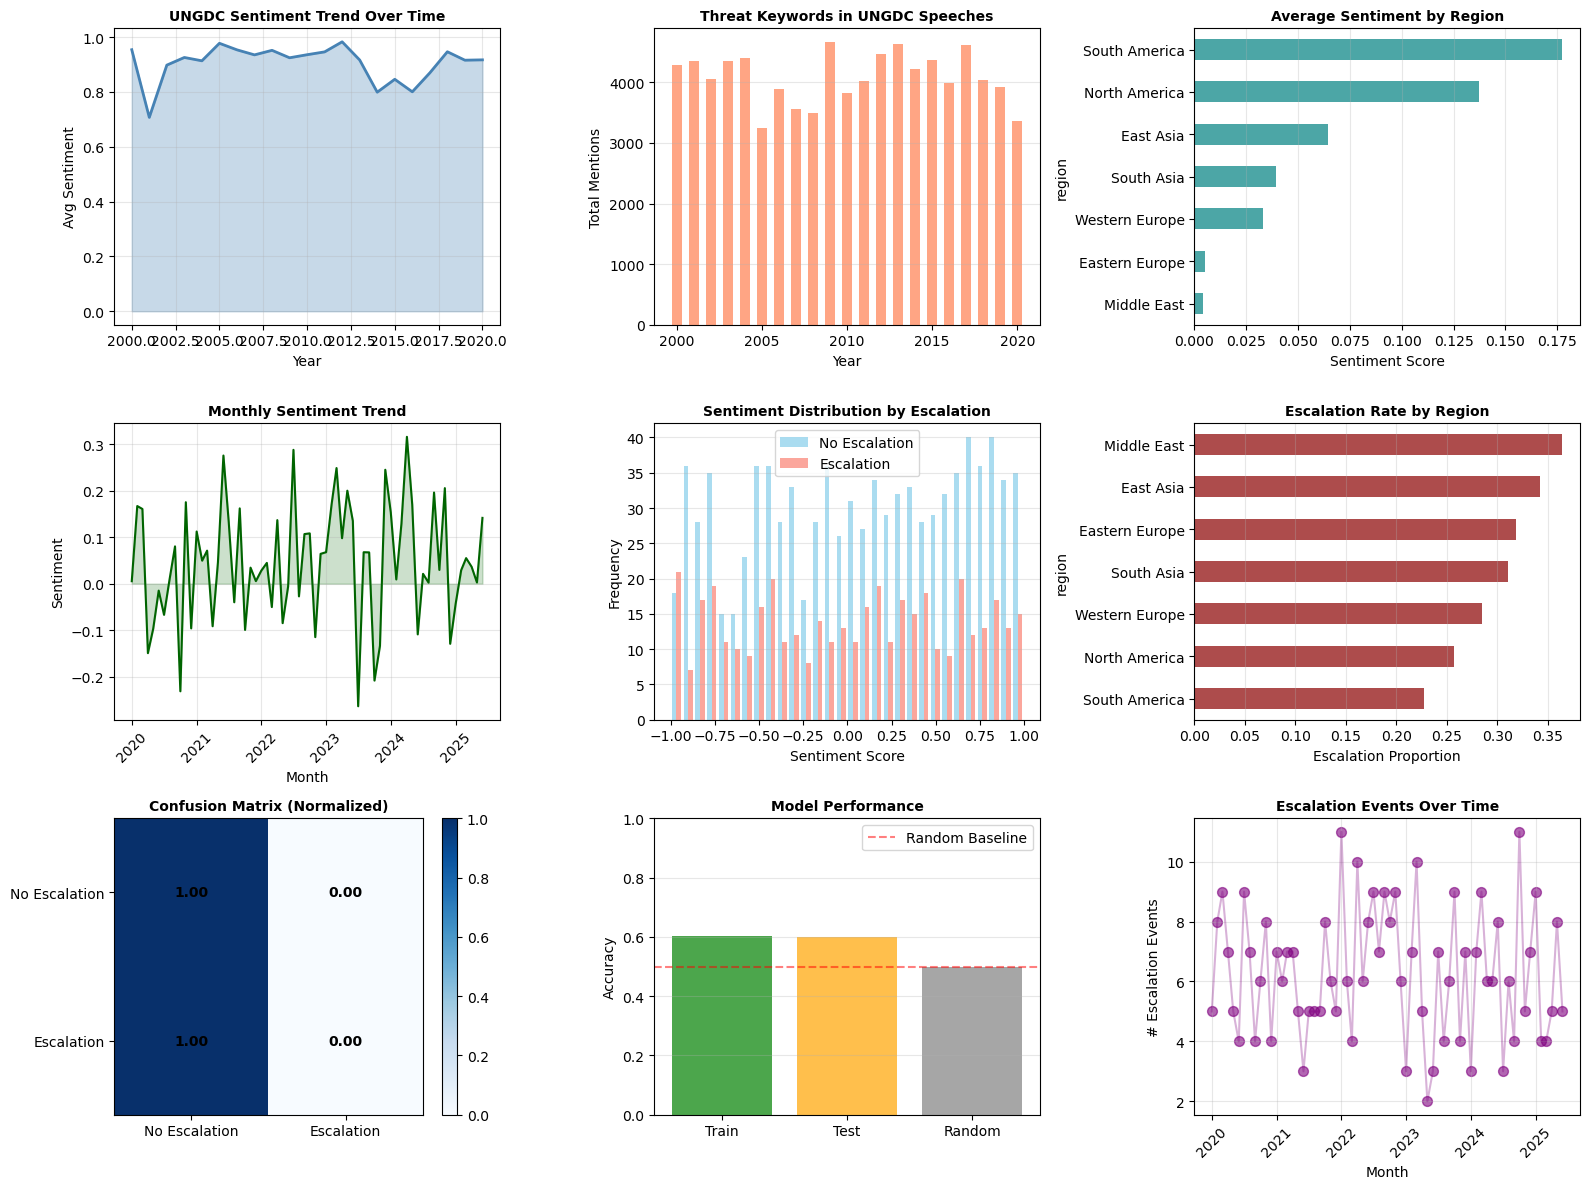

In [23]:
fig = plt.figure(figsize=(16, 12))

# 1. UNGDC Sentiment Trend
ax1 = plt.subplot(3, 3, 1)
yearly_data = ungdc_agg.groupby('year')[['sentiment_mean']].mean()
ax1.plot(yearly_data.index, yearly_data['sentiment_mean'], linewidth=2, color='steelblue')
ax1.fill_between(yearly_data.index, yearly_data['sentiment_mean'], alpha=0.3, color='steelblue')
ax1.set_title('UNGDC Sentiment Trend Over Time', fontsize=10, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Sentiment')
ax1.grid(True, alpha=0.3)

# 2. UNGDC Threat Keywords Trend
ax2 = plt.subplot(3, 3, 2)
yearly_threats = ungdc_agg.groupby('year')[['threat_count']].sum()
ax2.bar(yearly_threats.index, yearly_threats['threat_count'], color='coral', alpha=0.7, width=0.6)
ax2.set_title('Threat Keywords in UNGDC Speeches', fontsize=10, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Total Mentions')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Regional Sentiment Comparison
ax3 = plt.subplot(3, 3, 3)
region_sentiment.plot(kind='barh', ax=ax3, color='teal', alpha=0.7)
ax3.set_title('Average Sentiment by Region', fontsize=10, fontweight='bold')
ax3.set_xlabel('Sentiment Score')
ax3.grid(True, alpha=0.3, axis='x')

# 4. Sentiment Over Time (Structured Data)
ax4 = plt.subplot(3, 3, 4)
monthly_sent = df.groupby('month')['social_media_sentiment'].mean()
ax4.plot(monthly_sent.index, monthly_sent.values, linewidth=1.5, color='darkgreen')
ax4.fill_between(monthly_sent.index, monthly_sent.values, alpha=0.2, color='darkgreen')
ax4.set_title('Monthly Sentiment Trend', fontsize=10, fontweight='bold')
ax4.set_xlabel('Month')
ax4.set_ylabel('Sentiment')
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

# 5. Sentiment Distribution by Escalation
ax5 = plt.subplot(3, 3, 5)
no_esc = df[df['conflict_escalation_6m'] == 0]['social_media_sentiment']
esc = df[df['conflict_escalation_6m'] == 1]['social_media_sentiment']
ax5.hist([no_esc, esc], bins=30, label=['No Escalation', 'Escalation'], 
         color=['skyblue', 'salmon'], alpha=0.7)
ax5.set_title('Sentiment Distribution by Escalation', fontsize=10, fontweight='bold')
ax5.set_xlabel('Sentiment Score')
ax5.set_ylabel('Frequency')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 6. Escalation by Region
ax6 = plt.subplot(3, 3, 6)
region_escalation = df.groupby('region')['conflict_escalation_6m'].mean().sort_values()
region_escalation.plot(kind='barh', ax=ax6, color='darkred', alpha=0.7)
ax6.set_title('Escalation Rate by Region', fontsize=10, fontweight='bold')
ax6.set_xlabel('Escalation Proportion')
ax6.grid(True, alpha=0.3, axis='x')

# 7. Confusion Matrix Heatmap
ax7 = plt.subplot(3, 3, 7)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
im = ax7.imshow(cm_normalized, cmap='Blues', aspect='auto')
ax7.set_xticks([0, 1])
ax7.set_yticks([0, 1])
ax7.set_xticklabels(['No Escalation', 'Escalation'])
ax7.set_yticklabels(['No Escalation', 'Escalation'])
ax7.set_title('Confusion Matrix (Normalized)', fontsize=10, fontweight='bold')
for i in range(2):
    for j in range(2):
        text = ax7.text(j, i, f'{cm_normalized[i, j]:.2f}',
                       ha="center", va="center", color="black", fontweight='bold')
plt.colorbar(im, ax=ax7)

# 8. Model Accuracy Comparison
ax8 = plt.subplot(3, 3, 8)
accuracies = [train_acc, test_acc, 0.5]
labels = ['Train', 'Test', 'Random']
colors = ['green', 'orange', 'gray']
ax8.bar(labels, accuracies, color=colors, alpha=0.7)
ax8.set_title('Model Performance', fontsize=10, fontweight='bold')
ax8.set_ylabel('Accuracy')
ax8.set_ylim([0, 1])
ax8.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random Baseline')
ax8.grid(True, alpha=0.3, axis='y')
ax8.legend()

# 9. Escalation Timeline
ax9 = plt.subplot(3, 3, 9)
escalation_timeline = df.groupby('month')['conflict_escalation_6m'].sum()
ax9.scatter(escalation_timeline.index, escalation_timeline.values, 
           alpha=0.6, s=50, color='purple')
ax9.plot(escalation_timeline.index, escalation_timeline.values, alpha=0.3, color='purple')
ax9.set_title('Escalation Events Over Time', fontsize=10, fontweight='bold')
ax9.set_xlabel('Month')
ax9.set_ylabel('# Escalation Events')
ax9.grid(True, alpha=0.3)
ax9.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('conflict_analysis_results.png', dpi=300, bbox_inches='tight')
print("✓ Saved: conflict_analysis_results.png")

# PART 5: SUMMARY STATISTICS

In [24]:
print(f"""
DATASETS:
  UNGDC: {len(ungdc):,} speeches, {ungdc['year'].min()}-{ungdc['year'].max()}
  Conflict: {len(df):,} monthly records, {df['region'].nunique()} regions

SENTIMENT:
  Overall mean: {df['social_media_sentiment'].mean():.3f}
  Correlation w/ escalation: {correlation:.3f}
  Regions with highest sentiment: {region_sentiment.idxmax()}
  Regions with lowest sentiment: {region_sentiment.idxmin()}

THREATS:
  Total keyword mentions: {int(ungdc_agg['threat_count'].sum()):,}
  Peak year: {ungdc_agg.groupby('year')['threat_count'].sum().idxmax()}

ESCALATION:
  No escalation: {(df['conflict_escalation_6m']==0).sum()} ({100*(df['conflict_escalation_6m']==0).mean():.1f}%)
  With escalation: {(df['conflict_escalation_6m']==1).sum()} ({100*(df['conflict_escalation_6m']==1).mean():.1f}%)

MODEL:
  Training accuracy: {train_acc:.1%}
  Testing accuracy: {test_acc:.1%}
  Model coefficient: {model.coef_[0][0]:.3f}
  
NEXT STEPS:
  • Add temporal lag features (t-1, t-2)
  • Include threat frequency from UNGDC
  • Try ensemble methods (Random Forest, XGBoost)
  • Improve feature engineering
  • Validate on held-out events
""")


DATASETS:
  UNGDC: 3,093 speeches, 2000-2020
  Conflict: 1,320 monthly records, 7 regions

SENTIMENT:
  Overall mean: 0.045
  Correlation w/ escalation: -0.046
  Regions with highest sentiment: South America
  Regions with lowest sentiment: Middle East

THREATS:
  Total keyword mentions: 85,781
  Peak year: 2009

ESCALATION:
  No escalation: 905 (68.6%)
  With escalation: 415 (31.4%)

MODEL:
  Training accuracy: 60.2%
  Testing accuracy: 60.0%
  Model coefficient: -0.192

NEXT STEPS:
  • Add temporal lag features (t-1, t-2)
  • Include threat frequency from UNGDC
  • Try ensemble methods (Random Forest, XGBoost)
  • Improve feature engineering
  • Validate on held-out events

